In [5]:
import pandas as pd

path = "/work/keisuke-o/ws/tprt/datasets/dataset_xu_2024/Elevators/split_1/train_target.csv"
df = pd.read_csv(path, header=None)

In [6]:
df.head()

,0
0,1.409876
1,1.860687
2,1.710417
3,1.560146
4,1.259605


In [7]:
import numpy as np

In [8]:
arr = np.array(df)
arr

array([[1.4098757 ],
       [1.86068693],
       [1.71041652],
       ...,
       [0.20771243],
       [0.05744202],
       [0.20771243]])

In [9]:
# root mean square error with 0
y_pred = np.zeros_like(arr)
y_true = arr

def root_mean_square_error(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

rmse = root_mean_square_error(y_true, y_pred)
rmse

1.0

In [1]:
import torch

# def rbf_kernel(X1, X2, lengthscale=1.0, variance=1.0):
#     """
#     Computes the RBF kernel matrix between two sets of points.
#     """
#     lengthscale = torch.as_tensor(lengthscale, dtype=X1.dtype, device=X1.device)
#     variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
#     sqdist = torch.cdist(X1, X2, p=2).pow(2)
#     return variance * torch.exp(-0.5 * sqdist / lengthscale**2)

def rbf_kernel(X1, X2, lengthscale, variance=1.0):
    """
    Computes the RBF kernel matrix with ARD support.

    Args:
        X1 (torch.Tensor): A tensor of size (N, D).
        X2 (torch.Tensor): A tensor of size (M, D).
        lengthscale (torch.Tensor): A tensor of size (D,) representing the lengthscale for each dimension.
        variance (float): The kernel variance.
    """
    # Ensure variance is a tensor on the correct device
    variance = torch.as_tensor(variance, dtype=X1.dtype, device=X1.device)
    
    # Scale each dimension of X1 and X2 by the corresponding lengthscale
    # This uses broadcasting to efficiently perform the operation
    X1_scaled = X1 / lengthscale
    X2_scaled = X2 / lengthscale
    
    # Compute the squared Euclidean distance in the scaled space
    sqdist = torch.cdist(X1_scaled, X2_scaled, p=2).pow(2)
    
    return variance * torch.exp(-0.5 * sqdist)

# --- Helper class for Priors ---
class GammaPrior:
    def __init__(self, concentration, rate):
        self.concentration = concentration
        self.rate = rate

    def log_prob(self, x):
        # Log probability density of Gamma distribution (constants omitted)
        return (self.concentration - 1.0) * torch.log(x.clamp(min=1e-9)) - self.rate * x

class LogNormalPrior:
    def __init__(self, loc, scale):
        self.loc = loc
        self.scale = scale
        self.var = scale**2

    def log_prob(self, x):
        # Log probability density of LogNormal distribution (constants omitted)
        log_x = torch.log(x.clamp(min=1e-9))
        return -log_x - (log_x - self.loc)**2 / (2 * self.var)


import torch
import torch.nn as nn
import torch.optim as optim
import math
from torch.utils.data import DataLoader, TensorDataset
import logging
import numpy as np


class SparseTPRTMiniBatch(nn.Module):
    """
    【交互更新 SVI修正版】
    Eステップ（変分パラメータ更新）とMステップ（ハイパーパラメータ更新）を
    交互に行う確率的変分EMアルゴリズムを実装。
    """
    def __init__(self, X, y, M, nu_f=2.1, nu_e=2.1,
                 kernel_lengthscale=None, kernel_variance=1.0,
                 likelihood_sigma=1.0, device=None):
        super().__init__()

        if device is None:
            self.device = X.device
        else:
            self.device = torch.device(device)

        self.register_buffer('X_full', X.to(self.device))
        self.register_buffer('y_full', y.view(-1, 1).to(self.device))

        if self.X_full.ndim == 1: self.X_full = self.X_full.unsqueeze(1)
        if self.y_full.ndim == 1: self.y_full = self.y_full.unsqueeze(1)

        self.N, self.D = self.X_full.shape
        self.M = M
        dtype = self.X_full.dtype

        # --- ARD/Isotropic 自動対応 ---
        if kernel_lengthscale is None:
            kernel_lengthscale = torch.ones(self.D, dtype=dtype)
        else:
            kernel_lengthscale = torch.as_tensor(kernel_lengthscale, dtype=dtype)
        if kernel_lengthscale.ndim == 0:
            kernel_lengthscale = kernel_lengthscale.repeat(self.D)
        if kernel_lengthscale.shape[0] != self.D:
            raise ValueError(f"lengthscale must be a scalar or a vector of length D={self.D}")

        # --- Mステップで更新するハイパーパラメータ ---
        self.log_kernel_lengthscale = nn.Parameter(torch.log(kernel_lengthscale))
        self.log_kernel_variance = nn.Parameter(torch.log(torch.tensor(kernel_variance, dtype=dtype)))
        self.log_nu_f = nn.Parameter(torch.log(torch.tensor(nu_f, dtype=dtype)))
        self.log_nu_epsilon = nn.Parameter(torch.log(torch.tensor(nu_e, dtype=dtype)))
        self.log_sigma_sq = nn.Parameter(torch.log(torch.tensor(likelihood_sigma**2, dtype=dtype)))
        self.Z = nn.Parameter(self._initialize_inducing_points())

        # --- Priors ---
        self.lengthscale_prior = GammaPrior(3.0, 6.0)
        self.variance_prior = GammaPrior(2.0, 0.15)
        self.sigma_sq_prior = GammaPrior(1.1, 0.05)
        self.nu_prior = LogNormalPrior(loc=1.0, scale=1.0)

        # --- Eステップで更新する変分パラメータ (Bufferとして保持) ---
        self.register_buffer('m_u', torch.zeros(self.M, 1, dtype=dtype))
        self.register_buffer('S_u', torch.eye(self.M, dtype=dtype))
        self.register_buffer('alpha_r', torch.tensor(1.0, dtype=dtype))
        self.register_buffer('beta_r', torch.tensor(1.0, dtype=dtype))

        self.to(self.device)

    def _initialize_inducing_points(self):
        min_bounds = self.X_full.min(dim=0).values
        max_bounds = self.X_full.max(dim=0).values
        sobol_engine = torch.quasirandom.SobolEngine(dimension=self.D, scramble=True, seed=0)
        sobol_points_unit = sobol_engine.draw(self.M).to(dtype=self.X_full.dtype, device=self.device)
        return min_bounds + sobol_points_unit * (max_bounds - min_bounds)

    def _get_hyperparams(self):
        return {
            "nu_f": torch.exp(self.log_nu_f),
            "nu_epsilon": torch.exp(self.log_nu_epsilon),
            "sigma_sq": torch.exp(self.log_sigma_sq),
            "lengthscale": torch.exp(self.log_kernel_lengthscale),
            "variance": torch.exp(self.log_kernel_variance)
        }

    def _e_step(self, X_batch, y_batch, rho):
        """
        E-Step: ミニバッチ情報を使って変分パラメータを確率的に更新する。
        """
        with torch.no_grad():
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            
            # --- 1. バッチ局所的な q(λ) を計算 ---
            # この計算には現在のグローバルな q(u), q(r) が必要
            K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
            k_ii_batch = params['variance'].expand(X_batch.shape[0])

            if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
            else: expected_r_inv = self.beta_r
            
            KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
            expected_f_mean = K_XZ_batch @ KZZ_inv_m_u
            KXZ_KZZ_inv = torch.cholesky_solve(K_XZ_batch.T, L_ZZ).T
            
            var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
            var_f_term2 = (KXZ_KZZ_inv @ self.S_u @ KXZ_KZZ_inv.T).diag()
            var_f = (var_f_term1 + var_f_term2).unsqueeze(1)
            
            expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
            alpha_lambda_local = params['nu_epsilon'] / 2.0 + 0.5
            beta_lambda_local = params['nu_epsilon'] / 2.0 + (0.5 / params['sigma_sq']) * expected_sq_error
            
            # --- 2. q(u), q(r) の局所的な最適値を計算 ---
            expected_r = self.alpha_r / self.beta_r
            expected_lambda = alpha_lambda_local.squeeze() / beta_lambda_local.squeeze()
            c = expected_lambda / params['sigma_sq']
            
            # q(u) の更新式
            B = (K_XZ_batch.T * c) @ K_XZ_batch
            precision_inner = expected_r * K_ZZ + B
            L_precision_inner = torch.linalg.cholesky(precision_inner + torch.eye(self.M, dtype=K_ZZ.dtype, device=K_ZZ.device) * 1e-6)
            tmp_S = torch.cholesky_solve(K_ZZ, L_precision_inner)
            S_u_local = K_ZZ @ tmp_S
            y_term = K_XZ_batch.T @ (y_batch.squeeze() * c)
            m_u_unscaled = torch.cholesky_solve(y_term.unsqueeze(1), L_precision_inner)
            m_u_local = K_ZZ @ m_u_unscaled
            
            # q(r) の更新式
            trace_term = torch.trace(torch.cholesky_solve(S_u_local, L_ZZ))
            KZZ_inv_m_u_local = torch.cholesky_solve(m_u_local, L_ZZ)
            mean_term = m_u_local.T @ KZZ_inv_m_u_local
            expected_u_quadratic = trace_term + mean_term
            
            alpha_r_local = params['nu_f'] / 2.0 + self.M / 2.0
            beta_r_local_val = params['nu_f'] / 2.0 + 0.5 * expected_u_quadratic.squeeze()

            # --- 3. グローバル変分パラメータをステップ更新 ---
            self.m_u.data = (1 - rho) * self.m_u.data + rho * m_u_local.data
            self.S_u.data = (1 - rho) * self.S_u.data + rho * S_u_local.data
            self.alpha_r.data = (1 - rho) * self.alpha_r.data + rho * alpha_r_local.data
            self.beta_r.data = (1 - rho) * self.beta_r.data + rho * beta_r_local_val.data

            # MステップでELBO計算に使うため、最新の局所的なλのパラメータを返す
            return alpha_lambda_local, beta_lambda_local

    def _m_step(self, optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch):
        """
        M-Step: ELBOに基づいてハイパーパラメータを更新する。
        """
        optimizer.zero_grad()
        elbo = self._calculate_elbo(X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)
        loss = -elbo
        loss.backward()
        optimizer.step()
        return elbo.item()
        
    def _calculate_elbo(self, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch):
        # この関数はMステップ専用。Eステップで更新された最新の変分パラメータを使ってELBOを計算する
        B = X_batch.shape[0]
        params = self._get_hyperparams()
        
        K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
        L_ZZ = torch.linalg.cholesky(K_ZZ)
        K_XZ_batch = rbf_kernel(X_batch, self.Z, params['lengthscale'], params['variance'])
        k_ii_batch = params['variance'].expand(B)
        
        # 期待対数尤度
        expected_log_lambda = torch.digamma(alpha_lambda_batch) - torch.log(beta_lambda_batch)
        expected_lambda = alpha_lambda_batch / beta_lambda_batch
        
        KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
        expected_f_mean = K_XZ_batch @ KZZ_inv_m_u

        if self.alpha_r > 1: expected_r_inv = self.beta_r / (self.alpha_r - 1.0)
        else: expected_r_inv = self.beta_r
        
        KXZ_KZZ_inv = torch.cholesky_solve(K_XZ_batch.T, L_ZZ).T
        var_f_term1 = expected_r_inv * (k_ii_batch - (KXZ_KZZ_inv * K_XZ_batch).sum(dim=1))
        var_f_term2 = (KXZ_KZZ_inv @ self.S_u @ KXZ_KZZ_inv.T).diag()
        var_f = (var_f_term1 + var_f_term2).unsqueeze(1)
        
        expected_sq_error = (y_batch - expected_f_mean).pow(2) + var_f
        log_lik_batch = 0.5 * torch.sum(expected_log_lambda - math.log(2 * math.pi) - torch.log(params['sigma_sq']) - \
                                  (expected_lambda / params['sigma_sq']) * expected_sq_error)
        log_lik = log_lik_batch * (self.N / B)

        # KLダイバージェンス
        p_alpha_r, p_beta_r = params['nu_f'] / 2.0, params['nu_f'] / 2.0
        kl_r = (self.alpha_r - p_alpha_r) * torch.digamma(self.alpha_r) - torch.lgamma(self.alpha_r) + torch.lgamma(p_alpha_r) + \
               p_alpha_r * (torch.log(self.beta_r) - torch.log(p_beta_r)) + self.alpha_r * (p_beta_r - self.beta_r) / self.beta_r
        
        expected_log_r = torch.digamma(self.alpha_r) - torch.log(self.beta_r)
        expected_r = self.alpha_r / self.beta_r
        L_S = torch.linalg.cholesky(self.S_u + torch.eye(self.M, dtype=self.S_u.dtype, device=self.S_u.device) * 1e-6)
        logdet_S_u = 2 * torch.sum(torch.log(torch.diag(L_S)))
        logdet_K_ZZ = 2 * torch.sum(torch.log(torch.diag(L_ZZ)))
        trace_KZZinv_Su = torch.trace(torch.cholesky_solve(self.S_u, L_ZZ))
        m_T_KZZinv_m = self.m_u.T @ KZZ_inv_m_u
        kl_u = 0.5 * (-logdet_S_u - self.M * expected_log_r + logdet_K_ZZ + expected_r * (trace_KZZinv_Su + m_T_KZZinv_m) - self.M).squeeze()
        
        p_alpha_lambda, p_beta_lambda = params['nu_epsilon'] / 2.0, params['nu_epsilon'] / 2.0
        kl_lambda_batch = torch.sum((alpha_lambda_batch - p_alpha_lambda) * torch.digamma(alpha_lambda_batch) - \
                    torch.lgamma(alpha_lambda_batch) + torch.lgamma(p_alpha_lambda) + \
                    p_alpha_lambda * (torch.log(beta_lambda_batch) - torch.log(p_beta_lambda)) + \
                    alpha_lambda_batch * (p_beta_lambda - beta_lambda_batch) / beta_lambda_batch)
        kl_lambda = kl_lambda_batch * (self.N / B)
        
        log_prior = self.lengthscale_prior.log_prob(params['lengthscale']).sum() + \
                    self.variance_prior.log_prob(params['variance']) + \
                    self.sigma_sq_prior.log_prob(params['sigma_sq']) + \
                    self.nu_prior.log_prob(params['nu_f']) + \
                    self.nu_prior.log_prob(params['nu_epsilon'])

        return log_lik - kl_u - kl_r - kl_lambda + log_prior

    def fit(self, epochs=100, batch_size=64, lr=0.01, rho=0.05):
        # ハイパーパラメータ専用のオプティマイザ
        parameters_to_optimize = [
            self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
            self.log_kernel_lengthscale, self.log_kernel_variance, self.Z
        ]
        optimizer = optim.Adam(parameters_to_optimize, lr=lr)
        
        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
        
        elbo_history = []
        print(f"Starting Variational EM optimization for {epochs} epochs with batch size {batch_size}...")
        for epoch in range(epochs):
            for i, (X_batch, y_batch) in enumerate(dataloader):
                # 1. E-Step: 変分パラメータを確率的更新
                alpha_lambda_batch, beta_lambda_batch = self._e_step(X_batch, y_batch, rho=rho)
                
                # 2. M-Step: ハイパーパラメータを勾配更新
                elbo = self._m_step(optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)
                
                elbo_history.append(elbo)
            
            if (epoch + 1) % 10 == 0:
                print(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo:.4f}")
        
        print("\nOptimization finished.")
        return elbo_history

    def predict(self, X_test):
        X_test = X_test.to(self.device)
        with torch.no_grad():
            params = self._get_hyperparams()
            K_ZZ = rbf_kernel(self.Z, self.Z, params['lengthscale'], params['variance']) + torch.eye(self.M, device=self.Z.device) * 1e-6
            L_ZZ = torch.linalg.cholesky(K_ZZ)
            K_star_Z = rbf_kernel(X_test, self.Z, params['lengthscale'], params['variance'])
            k_star_star = rbf_kernel(X_test, X_test, params['lengthscale'], params['variance']).diag()

            KZZ_inv_m_u = torch.cholesky_solve(self.m_u, L_ZZ)
            pred_mean = K_star_Z @ KZZ_inv_m_u

            K_star_Z_K_ZZ_inv = torch.cholesky_solve(K_star_Z.T, L_ZZ, upper=False).T
            
            gp_var = k_star_star - (K_star_Z_K_ZZ_inv * K_star_Z).sum(dim=1) + \
                     (K_star_Z_K_ZZ_inv @ self.S_u @ K_star_Z_K_ZZ_inv.T).diag()
            
            pred_nu = 2 * self.alpha_r
            pred_scale_sq = (gp_var * (self.beta_r / self.alpha_r)).unsqueeze(1)
            
            return pred_mean, pred_scale_sq, pred_nu
    
    def evaluate_model(self, epochs=100, batch_size=64, lr=0.01, rho=0.05,
                       X_test=None, y_test=None, eval_interval=10,
                       result_path=None):

        parameters_to_optimize = [
            self.log_nu_f, self.log_nu_epsilon, self.log_sigma_sq,
            self.log_kernel_lengthscale, self.log_kernel_variance, self.Z
        ]
        optimizer = optim.Adam(parameters_to_optimize, lr=lr)

        dataset = TensorDataset(self.X_full, self.y_full)
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

        can_evaluate = X_test is not None and y_test is not None and result_path is not None
        if can_evaluate:
            X_test_dev, y_test_dev = X_test.to(self.device), y_test.to(self.device)
            if not result_path.exists():
                result_path.parent.mkdir(parents=True, exist_ok=True)
                with open(result_path, 'w') as f:
                    f.write("epoch,rmse,elbo\n")

        print(f"Starting Variational EM optimization for {epochs} epochs with batch size {batch_size}...")
        for epoch in range(epochs):
            elbo_val = 0.0
            for i, (X_batch, y_batch) in enumerate(dataloader):
                # 1. E-Step
                alpha_lambda_batch, beta_lambda_batch = self._e_step(X_batch, y_batch, rho=rho)
                
                # 2. M-Step
                elbo_val = self._m_step(optimizer, X_batch, y_batch, alpha_lambda_batch, beta_lambda_batch)

            if can_evaluate and (epoch + 1) % eval_interval == 0:
                with torch.no_grad():
                    pred_mean, _, _ = self.predict(X_test_dev)
                    rmse = torch.sqrt(torch.mean((y_test_dev.view(-1) - pred_mean.view(-1))**2)).item()
                
                logging.info(f"Epoch {epoch+1}/{epochs}, Final Batch ELBO: {elbo_val:.4f}, Test RMSE: {rmse:.4f}")
                
                with open(result_path, 'a') as f:
                    f.write(f"{epoch+1},{rmse},{elbo_val}\n")
        
        if can_evaluate:
             with torch.no_grad():
                pred_mean, _, _ = self.predict(X_test_dev)
                rmse = torch.sqrt(torch.mean((y_test_dev.view(-1) - pred_mean.view(-1))**2)).item()
             
             if epochs > 0 and epochs % eval_interval != 0:
                 with open(result_path, 'a') as f:
                    f.write(f"{epochs},{rmse},{elbo_val}\n")
        
        print("\nOptimization finished.")

Using device: cpu
Starting Variational EM optimization for 500 epochs with batch size 50...


Epoch 10/500, Final Batch ELBO: -1362.0959
Epoch 20/500, Final Batch ELBO: -185.3194
Epoch 30/500, Final Batch ELBO: -133.1355
Epoch 40/500, Final Batch ELBO: -92.6667
Epoch 50/500, Final Batch ELBO: -57.6019
Epoch 60/500, Final Batch ELBO: -28.0857
Epoch 70/500, Final Batch ELBO: 0.4588
Epoch 80/500, Final Batch ELBO: 18.6352
Epoch 90/500, Final Batch ELBO: 43.8254
Epoch 100/500, Final Batch ELBO: 51.5557
Epoch 110/500, Final Batch ELBO: 67.6386
Epoch 120/500, Final Batch ELBO: 75.4265
Epoch 130/500, Final Batch ELBO: 82.1757
Epoch 140/500, Final Batch ELBO: 82.3761
Epoch 150/500, Final Batch ELBO: 94.3002
Epoch 160/500, Final Batch ELBO: 92.5087
Epoch 170/500, Final Batch ELBO: 98.3507
Epoch 180/500, Final Batch ELBO: 85.1211
Epoch 190/500, Final Batch ELBO: 84.4827
Epoch 200/500, Final Batch ELBO: 67.6529
Epoch 210/500, Final Batch ELBO: 93.7979
Epoch 220/500, Final Batch ELBO: 80.6725
Epoch 230/500, Final Batch ELBO: 89.8052
Epoch 240/500, Final Batch ELBO: 92.3758
Epoch 250/500, F

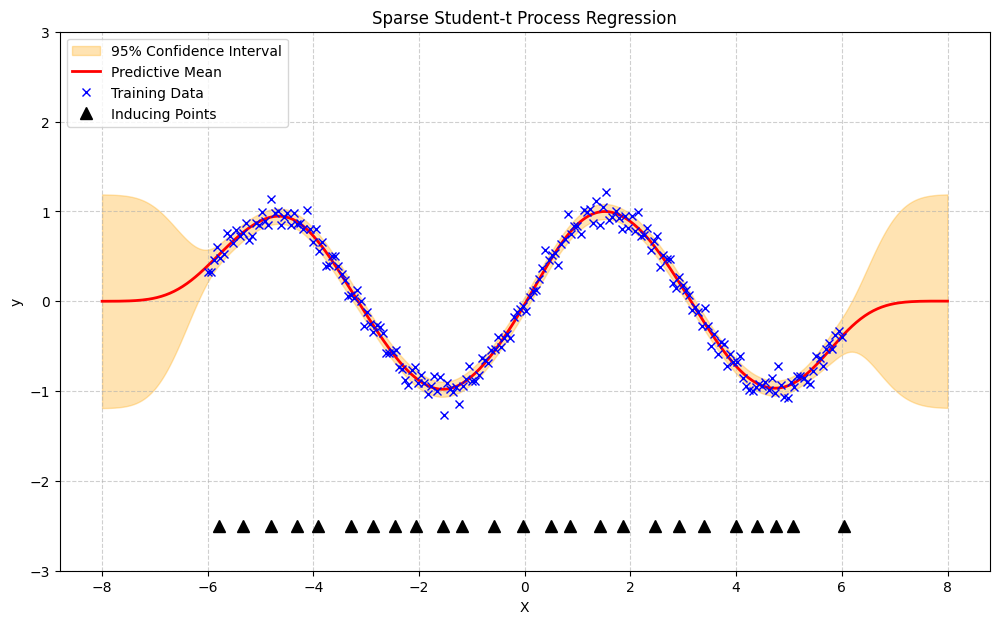

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t as student_t

# --- ここからが実行部分 ---
if __name__ == '__main__':
    # 0. 再現性のためのシード設定
    torch.manual_seed(42)
    np.random.seed(42)
    torch.set_default_dtype(torch.float64)

    # 1. トイデータの生成 (sin波 + ノイズ)
    N = 200
    X_np = np.linspace(-6, 6, N).reshape(-1, 1)
    y_np = np.sin(X_np) + np.random.normal(0, 0.1, size=(N, 1))
    
    # PyTorchテンソルに変換
    X_train = torch.from_numpy(X_np)
    y_train = torch.from_numpy(y_np)

    # 2. モデルのインスタンス化
    M = 25  # 誘導点の数
    device = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"Using device: {device}")
    
    model = SparseTPRTMiniBatch(X=X_train, y=y_train, M=M, device=device)

    # 3. モデルの学習
    model.fit(epochs=500, batch_size=50, lr=0.01, rho=0.1)

    # 4. 予測と可視化の準備
    X_test_np = np.linspace(-8, 8, 400).reshape(-1, 1)
    X_test = torch.from_numpy(X_test_np)
    
    pred_mean, pred_scale_sq, pred_nu = model.predict(X_test)

    # CPUにデータを移動してNumpy配列に変換
    pred_mean = pred_mean.cpu().numpy().flatten()
    pred_scale = np.sqrt(pred_scale_sq.cpu().numpy().flatten())
    pred_nu = pred_nu.cpu().item()
    inducing_points = model.Z.detach().cpu().numpy()

    # 予測t分布から95%信頼区間を計算
    # 自由度df、位置loc、スケールscaleのt分布のパーセント点関数
    # scipy.stats.t.ppf(q, df, loc=0, scale=1)
    alpha = 0.05  # 95%信頼区間
    t_value = student_t.ppf(1 - alpha / 2, df=pred_nu)
    lower_bound = pred_mean - t_value * pred_scale
    upper_bound = pred_mean + t_value * pred_scale

    # 5. 可視化
    plt.figure(figsize=(12, 7))
    # 信頼区間
    plt.fill_between(X_test_np.flatten(), lower_bound, upper_bound, color='orange', alpha=0.3, label='95% Confidence Interval')
    # 予測平均
    plt.plot(X_test_np, pred_mean, 'r-', lw=2, label='Predictive Mean')
    # 学習データ
    plt.plot(X_train.numpy(), y_train.numpy(), 'bx', label='Training Data')
    # 誘導点
    plt.plot(inducing_points, np.zeros_like(inducing_points) - 2.5, 'k^', markersize=8, label='Inducing Points')
    
    plt.title('Sparse Student-t Process Regression')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.legend(loc='upper left')
    plt.ylim(-3, 3)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()